# Week 4 - Real-world Retail Data Project

## Objective

Perform end-to-end retail sales analysis using real-world Walmart sales data to identify business trends, customer behavior, and sales performance.

---

## Tools Used

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn





## Project Workflow

1. Import Libraries  
2. Load Dataset  
3. Data Understanding  
4. Data Cleaning  
5. Sales Analysis  
6. Correlation Analysis  
7. Data Visualization  
8. Machine Learning Prediction  
9. Insights & Conclusion  


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

In [84]:
df = pd.read_csv("/content/Walmart_Sales.csv")

In [85]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [87]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [88]:
df.drop_duplicates(inplace=True)

df.fillna("Unknown", inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [89]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

print(store_sales)

Store
1     2.224028e+08
2     2.753824e+08
3     5.758674e+07
4     2.995440e+08
5     4.547569e+07
6     2.237561e+08
7     8.159828e+07
8     1.299512e+08
9     7.778922e+07
10    2.716177e+08
11    1.939628e+08
12    1.442872e+08
13    2.865177e+08
14    2.889999e+08
15    8.913368e+07
16    7.425243e+07
17    1.277821e+08
18    1.551147e+08
19    2.066349e+08
20    3.013978e+08
21    1.081179e+08
22    1.470756e+08
23    1.987506e+08
24    1.940160e+08
25    1.010612e+08
26    1.434164e+08
27    2.538559e+08
28    1.892637e+08
29    7.714155e+07
30    6.271689e+07
31    1.996139e+08
32    1.668192e+08
33    3.716022e+07
34    1.382498e+08
35    1.315207e+08
36    5.341221e+07
37    7.420274e+07
38    5.515963e+07
39    2.074455e+08
40    1.378703e+08
41    1.813419e+08
42    7.956575e+07
43    9.056544e+07
44    4.329309e+07
45    1.123953e+08
Name: Weekly_Sales, dtype: float64


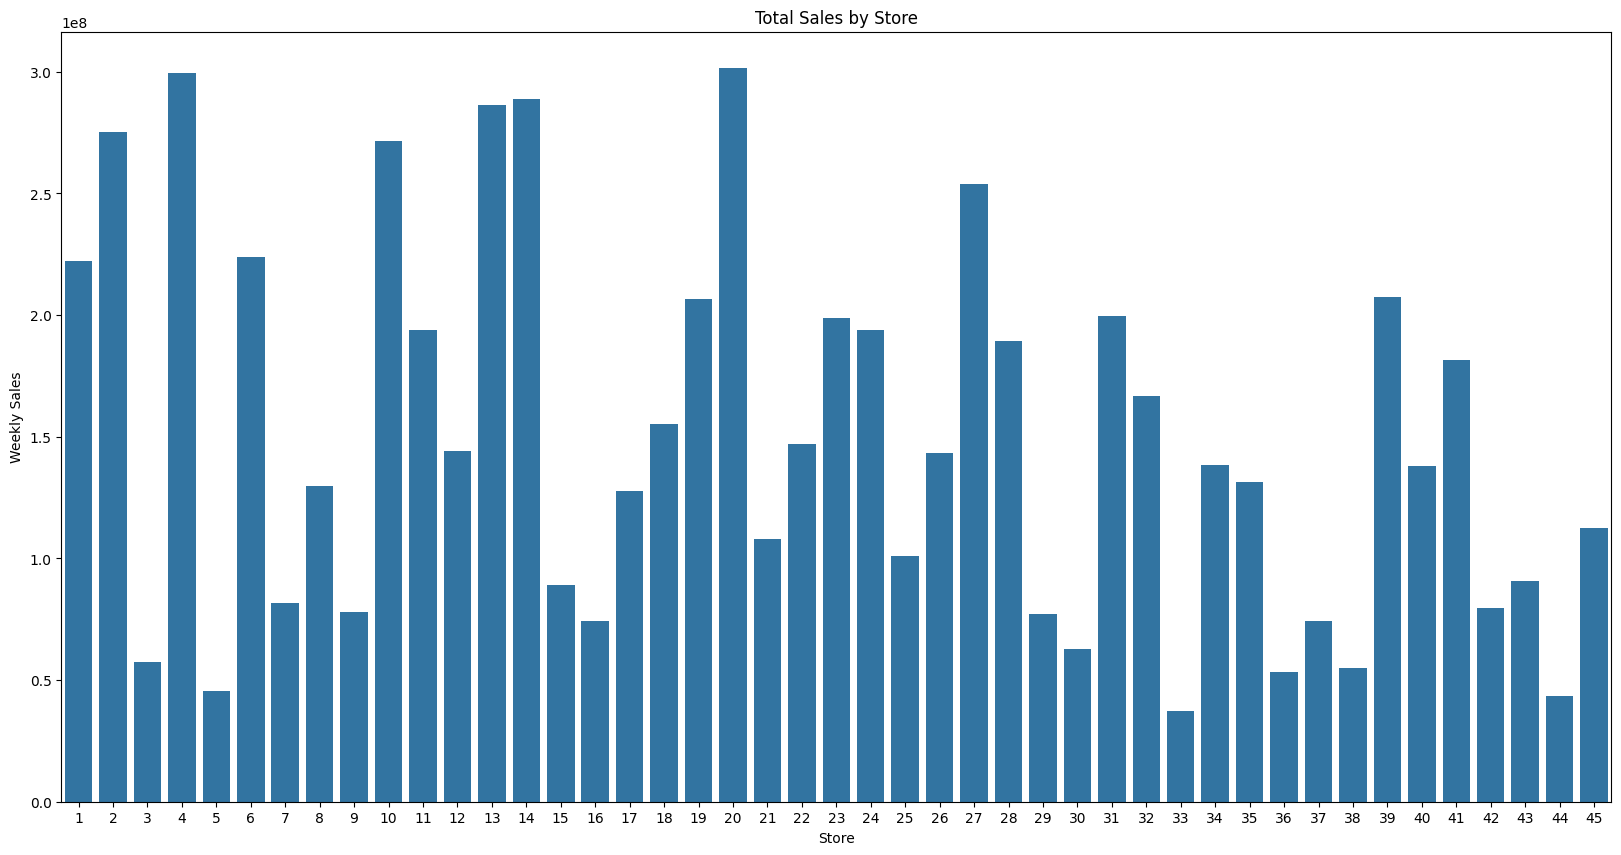

In [90]:
# Store-wise Sales Visualization

plt.figure(figsize=(20,10))

sns.barplot(x=store_sales.index, y=store_sales.values)

plt.title("Total Sales by Store")

plt.xlabel("Store")
plt.ylabel("Weekly Sales")

plt.show()

In [91]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

print(holiday_sales)

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


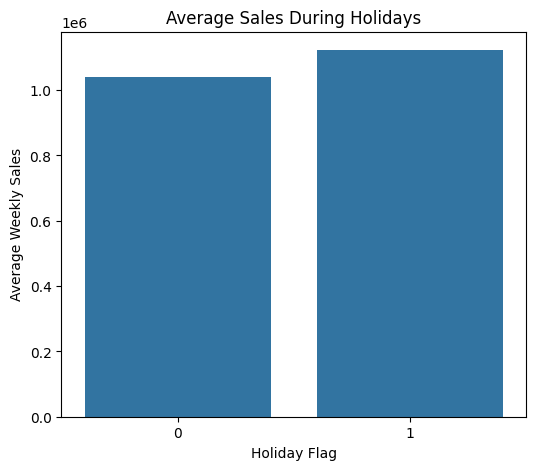

In [92]:
plt.figure(figsize=(6,5))

sns.barplot(x=holiday_sales.index, y=holiday_sales.values)

plt.title("Average Sales During Holidays")

plt.xlabel("Holiday Flag")
plt.ylabel("Average Weekly Sales")

plt.show()

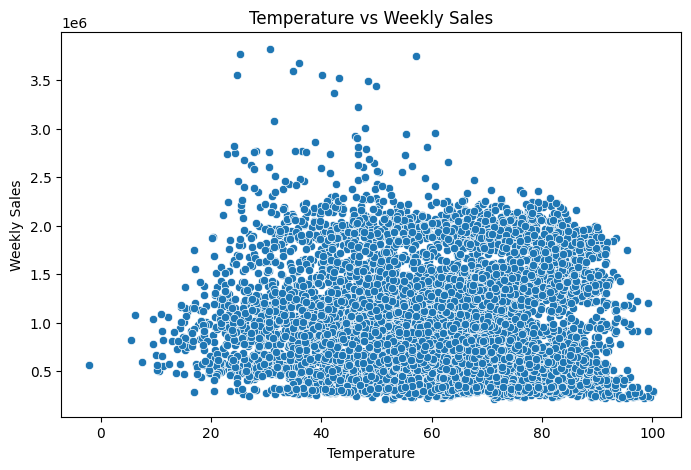

In [93]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['Temperature'], y=df['Weekly_Sales'])

plt.title("Temperature vs Weekly Sales")

plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")

plt.show()

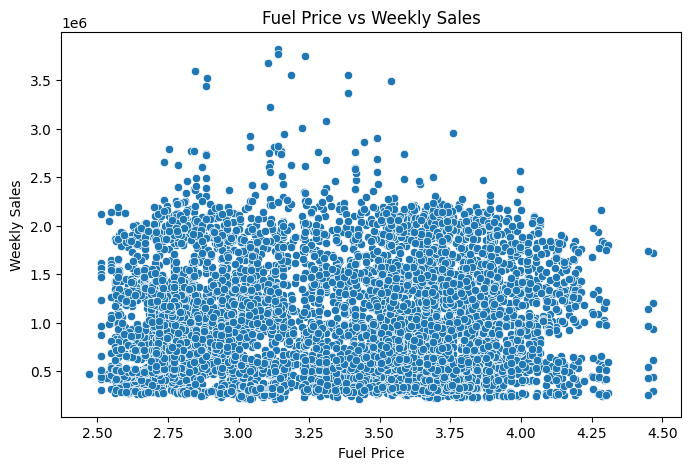

In [94]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['Fuel_Price'], y=df['Weekly_Sales'])

plt.title("Fuel Price vs Weekly Sales")

plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")

plt.show()

In [95]:
correlation = df.corr(numeric_only=True)

print(correlation)

                     Store  Weekly_Sales  Holiday_Flag  Temperature  \
Store         1.000000e+00     -0.335332 -4.386841e-16    -0.022659   
Weekly_Sales -3.353320e-01      1.000000  3.689097e-02    -0.063810   
Holiday_Flag -4.386841e-16      0.036891  1.000000e+00    -0.155091   
Temperature  -2.265908e-02     -0.063810 -1.550913e-01     1.000000   
Fuel_Price    6.002295e-02      0.009464 -7.834652e-02     0.144982   
CPI          -2.094919e-01     -0.072634 -2.162091e-03     0.176888   
Unemployment  2.235313e-01     -0.106176  1.096028e-02     0.101158   

              Fuel_Price       CPI  Unemployment  
Store           0.060023 -0.209492      0.223531  
Weekly_Sales    0.009464 -0.072634     -0.106176  
Holiday_Flag   -0.078347 -0.002162      0.010960  
Temperature     0.144982  0.176888      0.101158  
Fuel_Price      1.000000 -0.170642     -0.034684  
CPI            -0.170642  1.000000     -0.302020  
Unemployment   -0.034684 -0.302020      1.000000  


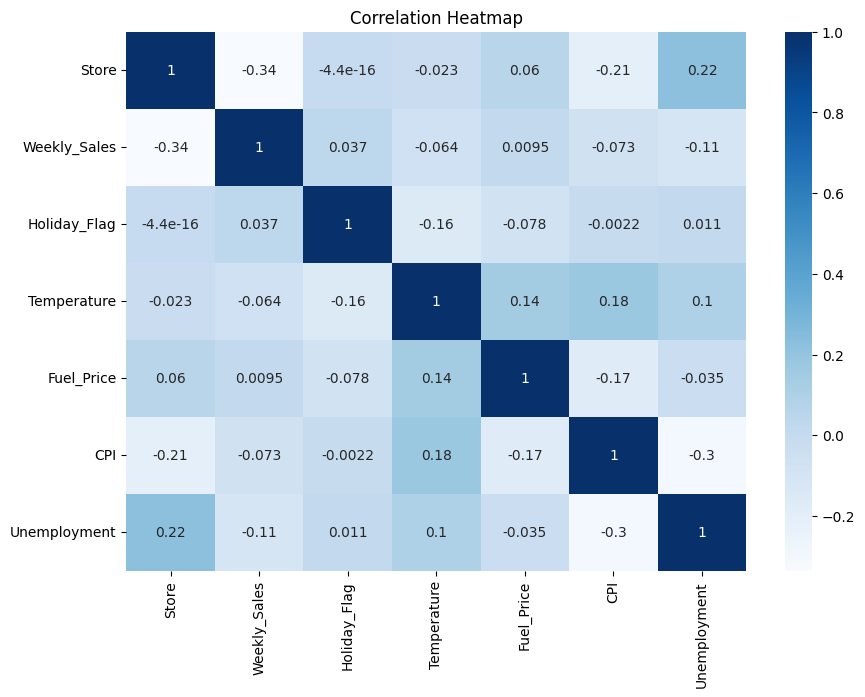

In [96]:
plt.figure(figsize=(10,7))

sns.heatmap(correlation, annot=True, cmap='Blues')

plt.title("Correlation Heatmap")

plt.show()

In [97]:
X = df[['Store', 'Holiday_Flag', 'Temperature',
        'Fuel_Price', 'CPI', 'Unemployment']]

y = df['Weekly_Sales']

In [98]:
model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [101]:
mae = mean_absolute_error(y_test, predictions)

mape = mean_absolute_percentage_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)

print("Mean Absolute Percentage Error:", mape)

print("R2 Score:", r2)

Mean Absolute Error: 475178.08409288194
Mean Absolute Percentage Error: 0.6754459739322478
R2 Score: 0.017498572820902725


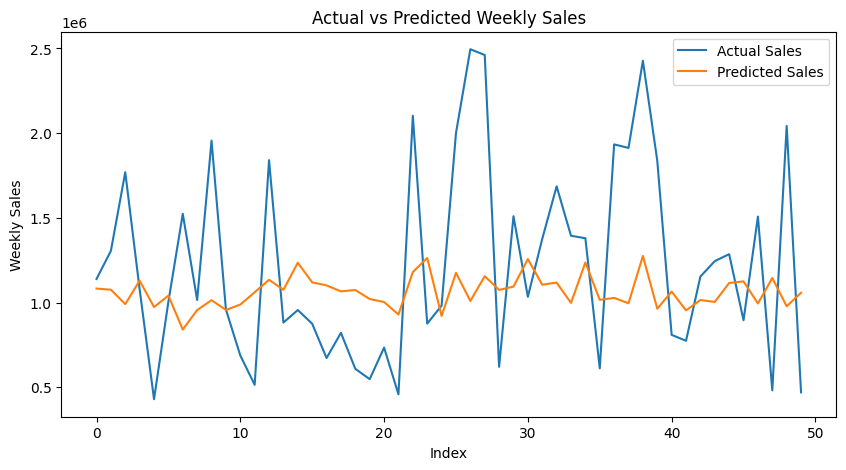

In [100]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual Sales')

plt.plot(predictions[:50], label='Predicted Sales')

plt.title("Actual vs Predicted Weekly Sales")

plt.xlabel("Index")
plt.ylabel("Weekly Sales")

plt.legend()

plt.show()

# Model Performance Analysis

The Linear Regression model showed limited prediction accuracy on the Walmart sales dataset.

Possible reasons include:
- Real-world retail sales are influenced by many external factors
- The dataset contains complex sales patterns
- Additional features and advanced models may improve performance

This project focused on understanding the end-to-end machine learning workflow and real-world retail analytics process.


# Key Insights

- Certain Walmart stores generated significantly higher weekly sales compared to others.
- Holiday periods showed increased average sales performance.
- Correlation analysis revealed relationships between sales and economic factors such as fuel price and unemployment.
- Real-world retail sales data contains complex patterns and variations.
- Machine learning models provided basic sales prediction insights using historical retail data.

# Conclusion

This project focused on real-world retail sales analysis using Walmart sales data.

The project included:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Correlation analysis
- Business trend visualization
- Sales prediction using Linear Regression

Key Learnings:
- Real-world datasets contain complex patterns
- Data visualization helps identify important business trends
- Machine learning can be applied for sales prediction
- End-to-end retail analytics workflow using Python and data science libraries

This project helped in developing practical data analysis and machine learning skills in a real-world retail domain.